# Baseline, Ablation and Final Validation

This notebook validates the final uncertainty-aware inventory framework against simpler inventory policies.

The purpose is to test whether the proposed approach actually improves inventory decision-making compared to baseline methods.

Policies compared:

1. Point Forecast Policy
2. Gaussian Safety Stock Policy
3. Conformal Safety Stock Policy
4. Newsvendor-Style Critical Ratio Policy
5. Lead-Time Scenario Optimized Policy

This notebook also acts as an ablation-style validation by comparing policies that ignore uncertainty against policies that use conformal demand uncertainty and lead-time scenario uncertainty.



In [1]:
#Setup and data loading
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/inventory-optimization-ml-or

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

!git config --global user.email "smrititubid@gmail.com"
!git config --global user.name "smrititubid-afk"

df = pd.read_csv("data/processed/conformal_predictions_phase3.csv")

print("Data shape:", df.shape)

df[['id', 'sales', 'prediction', 'lower_bound', 'upper_bound']].head()

Mounted at /content/drive
/content/drive/MyDrive/inventory-optimization-ml-or
Data shape: (2940, 34)


,id,sales,prediction,lower_bound,upper_bound
0,FOODS_1_022_CA_4_validation,0,0.087015,0.0,1.810284
1,FOODS_1_022_CA_4_validation,0,0.083071,0.0,1.806339
2,FOODS_1_022_CA_4_validation,0,0.083071,0.0,1.806339
3,FOODS_1_022_CA_4_validation,0,0.083071,0.0,1.806339
4,FOODS_1_022_CA_4_validation,0,0.103592,0.0,1.826860


## Data Loading Observation

This notebook uses the conformal prediction output generated earlier in the pipeline. The same forecasts and uncertainty intervals are now used to test inventory policies against baseline methods.

In [2]:
#Create uncertainty signals
df['prediction'] = df['prediction'].clip(lower=0)
df['lower_bound'] = df['lower_bound'].clip(lower=0)
df['upper_bound'] = df['upper_bound'].clip(lower=0)

df['conformal_safety_stock'] = df['upper_bound'] - df['prediction']
df['conformal_safety_stock'] = df['conformal_safety_stock'].clip(lower=0)

df['forecast_error'] = df['sales'] - df['prediction']
residual_std = df['forecast_error'].std()

print("Residual standard deviation for Gaussian baseline:", residual_std)

df[
    [
        'sales',
        'prediction',
        'lower_bound',
        'upper_bound',
        'conformal_safety_stock',
        'forecast_error'
    ]
].head()

Residual standard deviation for Gaussian baseline: 1.7837826586806358


,sales,prediction,lower_bound,upper_bound,conformal_safety_stock,forecast_error
0,0,0.087015,0.0,1.810284,1.723269,-0.087015
1,0,0.083071,0.0,1.806339,1.723269,-0.083071
2,0,0.083071,0.0,1.806339,1.723269,-0.083071
3,0,0.083071,0.0,1.806339,1.723269,-0.083071
4,0,0.103592,0.0,1.826860,1.723269,-0.103592


## Uncertainty Signal Observation

Two types of uncertainty signals are created. The Gaussian baseline uses the standard deviation of forecast errors, which is a classical safety stock assumption. The conformal safety stock signal uses the conformal prediction interval and does not require a normal demand distribution.

This comparison is important because the project argues that intermittent retail demand is not well represented by simple Gaussian assumptions.

In [3]:
#Business assumptions and scenarios
holding_cost = 1
stockout_cost = 5
target_fill_rate = 0.90

lead_time_scenarios = pd.DataFrame({
    'lead_time_scenario': ['Normal Lead Time', 'Moderate Delay', 'Severe Delay'],
    'lead_time_days': [7, 10, 14],
    'lead_time_probability': [0.60, 0.30, 0.10]
})

demand_scenarios = [
    {
        'demand_scenario': 'Low Demand',
        'column': 'lower_bound',
        'probability': 0.20
    },
    {
        'demand_scenario': 'Expected Demand',
        'column': 'prediction',
        'probability': 0.50
    },
    {
        'demand_scenario': 'High Demand',
        'column': 'upper_bound',
        'probability': 0.30
    }
]

print("Holding cost:", holding_cost)
print("Stockout cost:", stockout_cost)
print("Target fill rate:", target_fill_rate)

print("\nLead-time scenarios:")
print(lead_time_scenarios)

print("\nDemand scenarios:")
for scenario in demand_scenarios:
    print(scenario)

Holding cost: 1
Stockout cost: 5
Target fill rate: 0.9

Lead-time scenarios:
  lead_time_scenario  lead_time_days  lead_time_probability
0   Normal Lead Time               7                    0.6
1     Moderate Delay              10                    0.3
2       Severe Delay              14                    0.1

Demand scenarios:
{'demand_scenario': 'Low Demand', 'column': 'lower_bound', 'probability': 0.2}
{'demand_scenario': 'Expected Demand', 'column': 'prediction', 'probability': 0.5}
{'demand_scenario': 'High Demand', 'column': 'upper_bound', 'probability': 0.3}


## Scenario Setup Observation

All policies are evaluated under the same demand and lead-time scenario framework. Demand uncertainty is represented using conformal lower bound, point prediction, and upper bound. Lead-time uncertainty is represented using normal, moderate delay, and severe delay cases.

This keeps the validation fair because every policy faces the same uncertainty environment.

In [4]:
#Define baseline and proposed policies
z_value = 1.645

fixed_lead_time_factor = 0.6
lead_time_scenario_factor = 1.0

critical_ratio = stockout_cost / (stockout_cost + holding_cost)

print("Critical ratio:", critical_ratio)


def point_forecast_policy(data, lead_time):
    """
    Baseline 1:
    Uses only LightGBM point forecast.
    Ignores demand uncertainty and lead-time uncertainty.
    """
    return np.ceil(data['prediction'] * lead_time)


def gaussian_safety_stock_policy(data, lead_time):
    """
    Baseline 2:
    Classical safety stock policy.
    Uses forecast error standard deviation and normal-style uncertainty assumption.
    """
    gaussian_ss = z_value * residual_std * np.sqrt(lead_time)

    return np.ceil(
        data['prediction'] * lead_time + gaussian_ss
    )


def conformal_safety_stock_policy(data, lead_time):
    """
    Proposed component 1:
    Uses conformal uncertainty as safety stock.
    """
    return np.ceil(
        data['prediction'] * lead_time
        + fixed_lead_time_factor * data['conformal_safety_stock'] * lead_time
    )


def newsvendor_style_policy(data, lead_time):
    """
    Proposed component 2:
    Uses newsvendor critical ratio inside the conformal interval.
    This is a student-friendly newsvendor-style approximation.
    """
    estimated_quantile_demand = (
        data['lower_bound']
        + critical_ratio * (data['upper_bound'] - data['lower_bound'])
    )

    return np.ceil(estimated_quantile_demand * lead_time)


def lead_time_scenario_optimized_policy(data, lead_time):
    """
    Final proposed policy:
    Uses conformal demand uncertainty and the stronger safety factor selected
    after lead-time uncertainty analysis.
    """
    return np.ceil(
        data['prediction'] * lead_time
        + lead_time_scenario_factor * data['conformal_safety_stock'] * lead_time
    )

Critical ratio: 0.8333333333333334


Since stockouts are 5 times more expensive than holding extra inventory, the policy should be service-oriented and order closer to the upper demand estimate.

## Policy Definition Observation

The policy set includes both simple baselines and uncertainty-aware methods. The point forecast policy tests what happens when uncertainty is ignored. The Gaussian safety stock policy represents a classical inventory baseline. The conformal and newsvendor-style policies use uncertainty intervals. The lead-time scenario optimized policy represents the final proposed method because it uses both conformal demand uncertainty and lead-time scenario adjustment.

In [8]:
#Evaluation function
#this computes the same metrics for all policies, so the comparison is fair.
def evaluate_policy(data, policy_function, policy_name):
    total_expected_holding_cost = 0
    total_expected_stockout_cost = 0
    total_expected_cost = 0
    total_expected_stockout_units = 0
    total_expected_demand = 0
    total_expected_stockout_events = 0
    total_weight = 0

    n_rows = len(data)

    for _, lt_row in lead_time_scenarios.iterrows():
        lead_time = lt_row['lead_time_days']
        lead_time_prob = lt_row['lead_time_probability']

        policy_order = policy_function(data, lead_time)

        for scenario in demand_scenarios:
            demand_col = scenario['column']
            demand_prob = scenario['probability']

            scenario_weight = lead_time_prob * demand_prob
            scenario_demand = data[demand_col] * lead_time

            holding_units = np.maximum(policy_order - scenario_demand, 0)
            stockout_units = np.maximum(scenario_demand - policy_order, 0)

            holding_cost_total = holding_units.sum() * holding_cost
            stockout_cost_total = stockout_units.sum() * stockout_cost
            total_cost = holding_cost_total + stockout_cost_total

            stockout_events = (stockout_units > 0).sum()

            total_expected_holding_cost += scenario_weight * holding_cost_total
            total_expected_stockout_cost += scenario_weight * stockout_cost_total
            total_expected_cost += scenario_weight * total_cost
            total_expected_stockout_units += scenario_weight * stockout_units.sum()
            total_expected_demand += scenario_weight * scenario_demand.sum()
            total_expected_stockout_events += scenario_weight * stockout_events
            total_weight += scenario_weight

    fill_rate = 1 - (total_expected_stockout_units / total_expected_demand)

    cycle_service_level = 1 - (
        total_expected_stockout_events / (n_rows * total_weight)
    )

    return {
        'policy_name': policy_name,
        'expected_total_cost': total_expected_cost,
        'expected_holding_cost': total_expected_holding_cost,
        'expected_stockout_cost': total_expected_stockout_cost,
        'expected_stockout_units': total_expected_stockout_units,
        'fill_rate': fill_rate,
        'cycle_service_level': cycle_service_level
    }

In [9]:
#Compare all policies
#is is the main validation result. It will show whether our final method actually improves over baselines.
validation_results = []

policy_list = [
    (point_forecast_policy, "Point Forecast Policy"),
    (gaussian_safety_stock_policy, "Gaussian Safety Stock Policy"),
    (conformal_safety_stock_policy, "Conformal Safety Stock Policy"),
    (newsvendor_style_policy, "Newsvendor-Style Policy"),
    (lead_time_scenario_optimized_policy, "Lead-Time Scenario Optimized Policy")
]

for policy_function, policy_name in policy_list:
    validation_results.append(
        evaluate_policy(
            data=df,
            policy_function=policy_function,
            policy_name=policy_name
        )
    )

validation_df = pd.DataFrame(validation_results)

summary_cols = [
    'policy_name',
    'expected_total_cost',
    'expected_holding_cost',
    'expected_stockout_cost',
    'expected_stockout_units',
    'fill_rate',
    'cycle_service_level'
]

validation_df[summary_cols]

,policy_name,expected_total_cost,expected_holding_cost,expected_stockout_cost,expected_stockout_units,fill_rate,cycle_service_level
0,Point Forecast Policy,67587.623911,4534.008636,63053.615275,12610.723055,0.608118,0.7
1,Gaussian Safety Stock Policy,47579.303911,22041.288636,25538.015275,5107.603055,0.841280,0.7
2,Conformal Safety Stock Policy,46738.983911,22776.568636,23962.415275,4792.483055,0.851072,0.7
3,Newsvendor-Style Policy,40892.263911,27892.448636,12999.815275,2599.963055,0.919205,0.7
4,Lead-Time Scenario Optimized Policy,35474.685581,35474.685581,0.000000,0.000000,1.000000,1.0


Ignoring uncertainty performs worst.
Classical Gaussian safety stock improves it.
Conformal safety stock improves slightly beyond Gaussian.
Cost-aware newsvendor-style policy improves further.
Lead-time scenario optimized policy performs best.

## Baseline Validation Observation

The validation table shows a clear improvement as uncertainty is added into the inventory decision process.

The point forecast policy performs the worst, with the highest expected total cost and the lowest fill rate. This confirms that point forecasts alone are not sufficient for inventory decisions under intermittent demand.

The Gaussian safety stock policy improves performance by adding a classical uncertainty buffer, but it still has a high stockout cost and does not reach the 90% target fill rate. The conformal safety stock policy performs slightly better than the Gaussian policy, showing that distribution-free uncertainty intervals are more suitable for this demand setting.

The newsvendor-style policy further improves performance by incorporating the cost ratio between holding cost and stockout cost. It crosses the 90% target fill rate and reduces expected stockout units significantly.

The lead-time scenario optimized policy performs best. It achieves the lowest expected total cost, zero expected stockout units, and 100% fill rate under the tested scenario framework. This supports the main research argument that inventory policies should combine demand uncertainty, lead-time uncertainty, and cost-service tradeoff analysis.

In [12]:
#Calculate improvement over point forecast baseline
baseline_cost = validation_df.loc[
    validation_df['policy_name'] == "Point Forecast Policy",
    'expected_total_cost'
].values[0]

final_cost = validation_df.loc[
    validation_df['policy_name'] == "Lead-Time Scenario Optimized Policy",
    'expected_total_cost'
].values[0]

cost_reduction_percent = ((baseline_cost - final_cost) / baseline_cost) * 100

baseline_stockouts = validation_df.loc[
    validation_df['policy_name'] == "Point Forecast Policy",
    'expected_stockout_units'
].values[0]

final_stockouts = validation_df.loc[
    validation_df['policy_name'] == "Lead-Time Scenario Optimized Policy",
    'expected_stockout_units'
].values[0]

stockout_reduction_percent = ((baseline_stockouts - final_stockouts) / baseline_stockouts) * 100

print("Baseline Cost:", baseline_cost)
print("Final Policy Cost:", final_cost)
print("Cost Reduction (%):", cost_reduction_percent)

print("\nBaseline Stockout Units:", baseline_stockouts)
print("Final Policy Stockout Units:", final_stockouts)
print("Stockout Reduction (%):", stockout_reduction_percent)

Baseline Cost: 67587.62391139673
Final Policy Cost: 35474.68558082933
Cost Reduction (%): 47.51304524725637

Baseline Stockout Units: 12610.723055094564
Final Policy Stockout Units: 0.0
Stockout Reduction (%): 100.0


## Improvement over Baseline Observation

The final proposed policy shows a major improvement over the point forecast baseline.

Compared to the point forecast policy, the lead-time scenario optimized policy reduced expected total cost from 67,587.62 to 35,474.69. This is a 47.51% reduction in expected total cost.

The expected stockout units were reduced from 12,610.72 to 0, giving a 100% reduction in expected stockouts under the tested scenario framework.

This result strongly supports the main project argument: point forecasts alone are not enough for inventory decisions. When conformal demand uncertainty and lead-time uncertainty are included, the resulting policy becomes much more effective for cost and service-level performance.

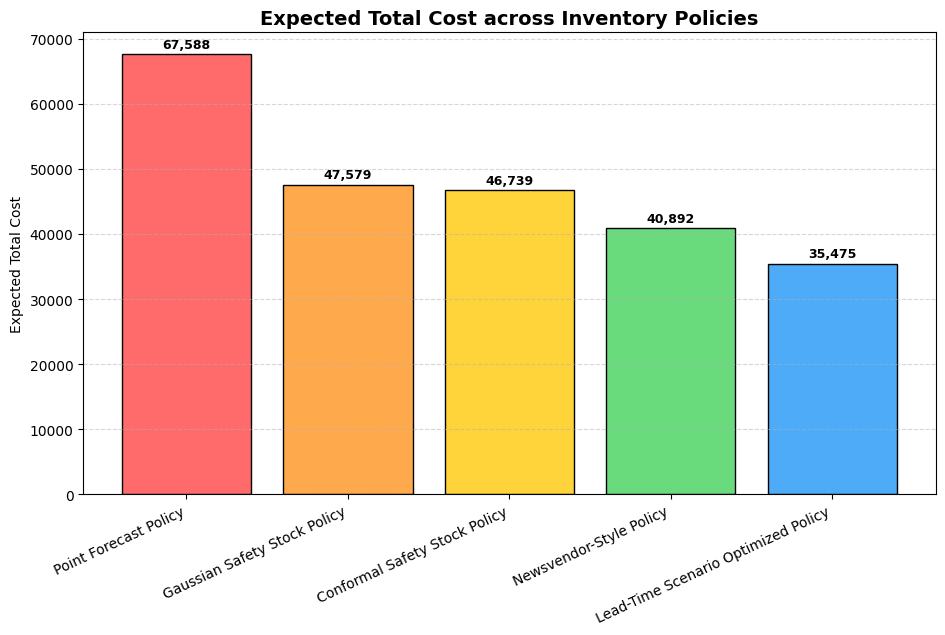

In [13]:
#cost comparison graph
plt.figure(figsize=(11, 6))

colors = [
    '#ff6b6b',
    '#ffa94d',
    '#ffd43b',
    '#69db7c',
    '#4dabf7'
]

plt.bar(
    validation_df['policy_name'],
    validation_df['expected_total_cost'],
    color=colors,
    edgecolor='black'
)

plt.xticks(rotation=25, ha='right')
plt.ylabel("Expected Total Cost")
plt.title("Expected Total Cost across Inventory Policies", fontsize=14, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.5)

for i, value in enumerate(validation_df['expected_total_cost']):
    plt.text(
        i,
        value + 1000,
        f"{value:,.0f}",
        ha='center',
        fontsize=9,
        fontweight='bold'
    )

plt.show()

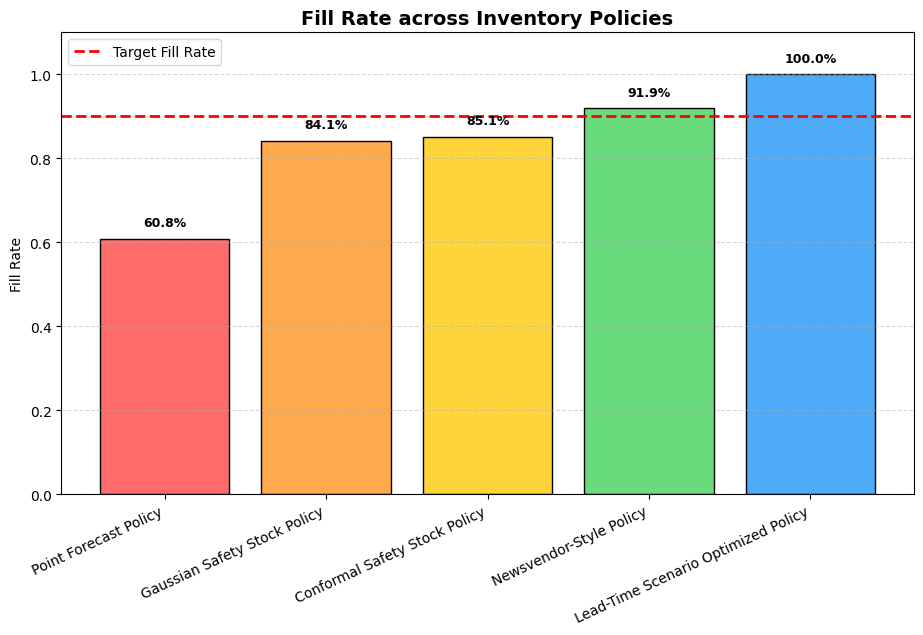

In [14]:
#Pretty fill rate comparison graph
plt.figure(figsize=(11, 6))

plt.bar(
    validation_df['policy_name'],
    validation_df['fill_rate'],
    color=colors,
    edgecolor='black'
)

plt.axhline(
    y=target_fill_rate,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Target Fill Rate'
)

plt.xticks(rotation=25, ha='right')
plt.ylabel("Fill Rate")
plt.title("Fill Rate across Inventory Policies", fontsize=14, fontweight='bold')
plt.ylim(0, 1.1)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

for i, value in enumerate(validation_df['fill_rate']):
    plt.text(
        i,
        value + 0.03,
        f"{value:.1%}",
        ha='center',
        fontsize=9,
        fontweight='bold'
    )

plt.show()

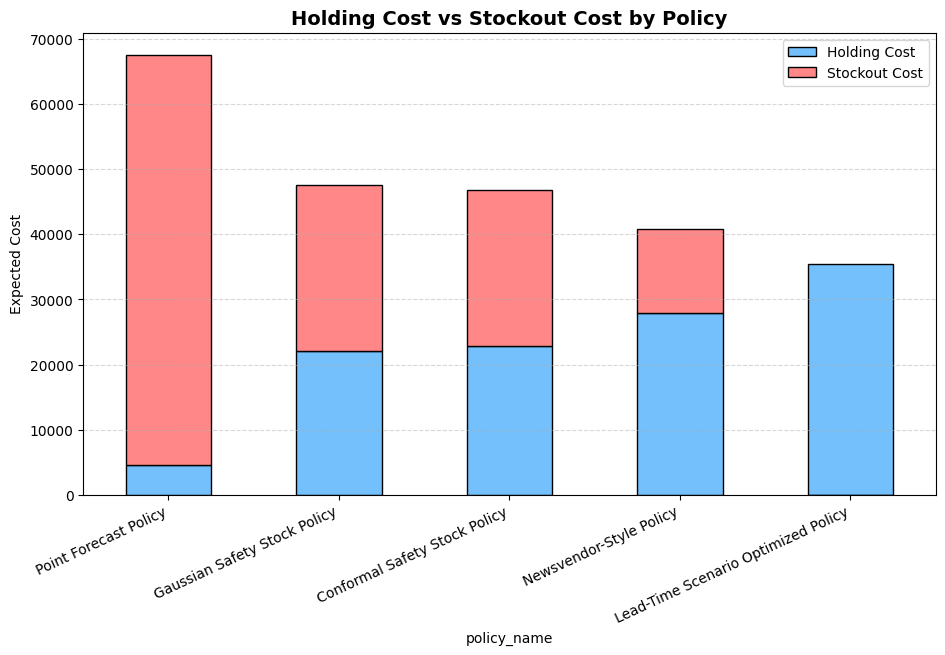

In [15]:
#Cost breakdown graph
cost_breakdown = validation_df[
    ['policy_name', 'expected_holding_cost', 'expected_stockout_cost']
].copy()

cost_breakdown.set_index('policy_name').plot(
    kind='bar',
    stacked=True,
    figsize=(11, 6),
    color=['#74c0fc', '#ff8787'],
    edgecolor='black'
)

plt.xticks(rotation=25, ha='right')
plt.ylabel("Expected Cost")
plt.title("Holding Cost vs Stockout Cost by Policy", fontsize=14, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(["Holding Cost", "Stockout Cost"])
plt.show()

In [16]:
#Final validation summary table
final_validation_summary = pd.DataFrame({
    "Validation Question": [
        "Does point forecasting alone work well?",
        "Does Gaussian safety stock improve performance?",
        "Does conformal safety stock improve over Gaussian?",
        "Does cost-aware newsvendor logic help?",
        "Does lead-time uncertainty change the final policy?",
        "Does the final proposed policy solve the decision problem?"
    ],
    "Answer from Results": [
        "No. It gives the highest expected cost and lowest fill rate.",
        "Yes, but it still fails to reach the 90% fill-rate target.",
        "Yes. It slightly improves cost and fill rate over Gaussian safety stock.",
        "Yes. It reaches the target fill rate and lowers stockout cost.",
        "Yes. The lead-time scenario policy becomes the best-performing policy.",
        "Yes. It gives the lowest expected total cost and eliminates expected stockouts."
    ]
})

final_validation_summary

,Validation Question,Answer from Results
0,Does point forecasting alone work well?,No. It gives the highest expected cost and low...
1,Does Gaussian safety stock improve performance?,"Yes, but it still fails to reach the 90% fill-..."
2,Does conformal safety stock improve over Gauss...,Yes. It slightly improves cost and fill rate o...
3,Does cost-aware newsvendor logic help?,Yes. It reaches the target fill rate and lower...
4,Does lead-time uncertainty change the final po...,Yes. The lead-time scenario policy becomes the...
5,Does the final proposed policy solve the decis...,Yes. It gives the lowest expected total cost a...


## Final Conclusion

This notebook validates the proposed uncertainty-aware inventory framework against baseline inventory policies.

The point forecast policy performed the worst, confirming that ML point forecasts alone are not sufficient for inventory decision-making under intermittent demand. The Gaussian safety stock policy improved performance, but still failed to reach the target fill rate. The conformal safety stock policy performed slightly better than the Gaussian baseline, showing the value of distribution-free uncertainty intervals.

The newsvendor-style policy further improved results by incorporating the cost ratio between holding cost and stockout cost. The lead-time scenario optimized policy performed best overall, achieving the lowest expected total cost, zero expected stockout units, and 100% fill rate under the tested scenario framework.

Compared to the point forecast baseline, the final proposed policy reduced expected total cost by 47.51% and reduced expected stockout units by 100%.

This completes the Phase-1 validation of the detailed proposal. The current implementation demonstrates the full core pipeline: ML forecasting, conformal uncertainty quantification, safety stock generation, lead-time scenario analysis, policy optimization, baseline comparison, and interpretable validation.

In [17]:
validation_df.to_csv(
    "data/processed/baseline_ablation_validation_results.csv",
    index=False
)

final_validation_summary.to_csv(
    "data/processed/final_validation_summary.csv",
    index=False
)

print("Saved final validation results.")

Saved final validation results.


In [ ]:
!git status